In [1]:
print("Notebook is working")

Notebook is working


In [2]:
import pandas as pd
import yfinance as yf

print("Imports worked")

Imports worked


In [3]:
ticker = "FICO"

stock_data = yf.download(ticker, start="2024-01-01", end="2026-01-01")

stock_data.head()

KeyboardInterrupt: 

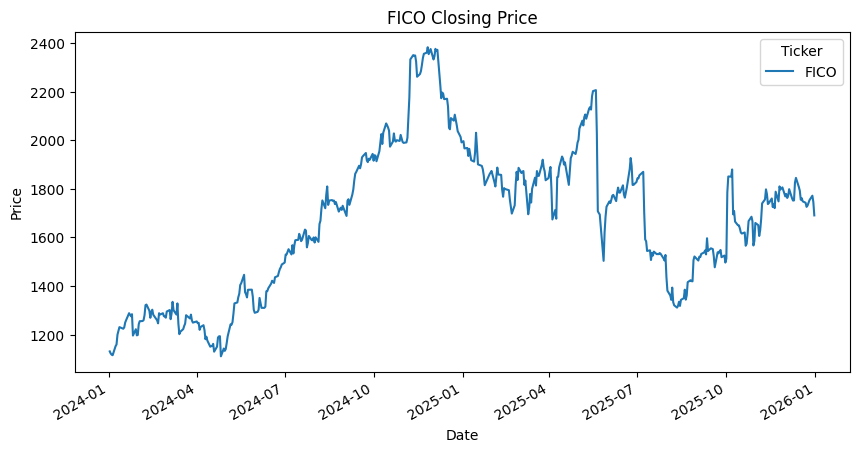

In [ ]:
import matplotlib.pyplot as plt

stock_data["Close"].plot(figsize=(10, 5), title="FICO Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
# Checking if can pull data via new market_data function
# date --> trading date, open --> price when market opened, high --> highing price in trading date, low --> lowest price in trading date, close --> final trading price at end of the day, adjusted_close --> close price adjusted for things like dividends and stock splits, volume --> number of shares traded
# adjusted_close --> important as we will calculate returns, accounting for stock splits and dividends allow for more accurate comparison of historical prices
import sys

sys.path.append("../src")

from market_data import get_stock_prices

fico_data = get_stock_prices("FICO", "2024-01-01", "2026-01-01")

fico_data.head()

Price,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,1152.400024,1158.010010,1119.880005,1131.160034,1131.160034,190800
1,2024-01-03,1131.160034,1135.000000,1116.119995,1122.369995,1122.369995,158600
2,2024-01-04,1124.089966,1132.930054,1115.099976,1117.459961,1117.459961,127700
3,2024-01-05,1115.520020,1132.400024,1113.189941,1115.459961,1115.459961,164600
4,2024-01-08,1120.920044,1154.520020,1115.810059,1152.430054,1152.430054,134200


In [ ]:
# Testing for all required testing ticker
tickers = ["FICO", "AAPL", "JPM", "XOM"]

for ticker in tickers:
    data = get_stock_prices(ticker, "2024-01-01", "2026-01-01")
    print(ticker, data.shape)

FICO (502, 7)
AAPL (502, 7)
JPM (502, 7)
XOM (502, 7)


In [ ]:
# Saving CSV to test CSV function, downloading full data set to data folder

fico_data.to_csv("../data/raw_FICO_prices.csv", index=False)

In [ ]:
# Test return table logic, utilising stock price and calculate returns functions
import sys

sys.path.append("../src")

from market_data import get_stock_prices, calculate_returns

fico_prices = get_stock_prices("FICO", "2024-01-01", "2026-01-01")

fico_daily_returns = calculate_returns(fico_prices, frequency="daily")
fico_weekly_returns = calculate_returns(fico_prices, frequency="weekly")
fico_monthly_returns = calculate_returns(fico_prices, frequency="monthly")

fico_weekly_returns.head()

print("Daily returns:")
print(fico_daily_returns.head())

print("Weekly returns:")
print(fico_weekly_returns.head())

print("Monthly returns:")
print(fico_monthly_returns.head())

Daily returns:
Price       date  adjusted_close    return
0     2024-01-03     1122.369995 -0.007771
1     2024-01-04     1117.459961 -0.004375
2     2024-01-05     1115.459961 -0.001790
3     2024-01-08     1152.430054  0.033143
4     2024-01-09     1159.660034  0.006274
Weekly returns:
Price       date  adjusted_close    return
0     2024-01-12     1230.989990  0.103572
1     2024-01-19     1260.209961  0.023737
2     2024-01-26     1196.359985 -0.050666
3     2024-02-02     1255.300049  0.049266
4     2024-02-09     1323.810059  0.054577
Monthly returns:
Price       date  adjusted_close    return
0     2024-02-29     1269.910034  0.059291
1     2024-03-31     1249.609985 -0.015985
2     2024-04-30     1133.329956 -0.093053
3     2024-05-31     1289.930054  0.138177
4     2024-06-30     1488.660034  0.154063


In [ ]:
# Save weekly returns to CSV
fico_weekly_returns.to_csv("../data/processed_FICO_returns.csv", index=False)

In [ ]:
# Error testing

calculate_returns(fico_prices, frequency="yearly")

ValueError: frequency must be 'daily', 'weekly', 'monthly'

In [ ]:
# Testing ETF benchmark returns
import sys

sys.path.append("../src")

from market_data import get_benchmark_returns

benchmark_returns = get_benchmark_returns("2024-01-01", "2026-01-01")

benchmark_returns.head()

Price,date,spy_return,qqq_return,xlk_return,xlf_return,xle_return,xly_return,xli_return,xlv_return,xlp_return,xlu_return,xlre_return
0,2024-01-12,0.018721,0.032287,0.044102,-0.003973,-0.023618,0.007763,0.006103,0.010063,0.010971,-0.018751,0.006363
1,2024-01-19,0.012063,0.028372,0.041251,0.008777,-0.030358,0.005346,0.003033,-0.007543,-0.010302,-0.036955,-0.021244
2,2024-01-26,0.010323,0.006244,0.007893,0.018982,0.050892,-0.018354,0.008715,-0.001362,0.008050,0.003772,-0.005426
3,2024-02-02,0.014238,0.012270,0.002429,0.008538,-0.008665,0.032852,0.018954,0.019531,0.021203,0.004574,-0.004677
4,2024-02-09,0.013857,0.018741,0.027690,0.002565,-0.002514,0.014550,0.011853,0.014226,-0.014291,-0.019841,0.002610


In [4]:
benchmark_returns.to_csv("../data/benchmark_returns.csv", index=False)

In [ ]:
# Returns benchmark ETF returns to test stock returns against
import sys

sys.path.append("../src")

from market_data import get_sector_etf

print(get_sector_etf("FICO"))
print(get_sector_etf("JPM"))
print(get_sector_etf("XOM"))

XLK
XLF
XLE


In [ ]:
# Test stock price function for multiple tickers

import sys
import os

sys.path.append("../src")

from market_data import get_stock_prices

tickers = ["FICO", "AAPL", "JPM", "XOM"]
           
for ticker in tickers:
    prices = get_stock_prices(ticker, "2024-01-01", "2026-01-01")
    print(ticker, prices.shape)
    print(prices.head())
    print()


FICO (502, 7)
        date         open         high          low        close  \
0 2024-01-02  1152.400024  1158.010010  1119.880005  1131.160034   
1 2024-01-03  1131.160034  1135.000000  1116.119995  1122.369995   
2 2024-01-04  1124.089966  1132.930054  1115.099976  1117.459961   
3 2024-01-05  1115.520020  1132.400024  1113.189941  1115.459961   
4 2024-01-08  1120.920044  1154.520020  1115.810059  1152.430054   

   adjusted_close  volume  
0     1131.160034  190800  
1     1122.369995  158600  
2     1117.459961  127700  
3     1115.459961  164600  
4     1152.430054  134200  

AAPL (502, 7)
        date        open        high         low       close  adjusted_close  \
0 2024-01-02  187.149994  188.440002  183.889999  185.639999      183.562195   
1 2024-01-03  184.220001  185.880005  183.429993  184.250000      182.187775   
2 2024-01-04  182.149994  183.089996  180.880005  181.910004      179.873947   
3 2024-01-05  181.990005  182.759995  180.169998  181.179993      179.1520

In [3]:
# Test weekly return function for four tickers

from market_data import calculate_returns

tickers = ["FICO", "AAPL", "JPM", "XOM"]

for ticker in tickers:
    prices = get_stock_prices(ticker, "2024-01-01", "2026-01-01")
    weekly_returns = calculate_returns(prices, frequency="weekly")
    
    print(ticker, weekly_returns.shape)
    print(weekly_returns.head())
    print()

FICO (104, 3)
        date  adjusted_close    return
0 2024-01-12     1230.989990  0.103572
1 2024-01-19     1260.209961  0.023737
2 2024-01-26     1196.359985 -0.050666
3 2024-02-02     1255.300049  0.049266
4 2024-02-09     1323.810059  0.054577

AAPL (104, 3)
        date  adjusted_close    return
0 2024-01-12      183.839066  0.026162
1 2024-01-19      189.415909  0.030335
2 2024-01-26      190.266312  0.004490
3 2024-02-02      183.769852 -0.034144
4 2024-02-09      186.974533  0.017439

JPM (104, 3)
        date  adjusted_close    return
0 2024-01-12      161.126526 -0.018691
1 2024-01-19      162.327484  0.007454
2 2024-01-26      164.205109  0.011567
3 2024-02-02      166.540283  0.014221
4 2024-02-09      166.807175  0.001603

XOM (104, 3)
        date  adjusted_close    return
0 2024-01-12       91.989632 -0.026113
1 2024-01-19       89.228554 -0.030015
2 2024-01-26       94.796707  0.062403
3 2024-02-02       93.848740 -0.010000
4 2024-02-09       93.664688 -0.001961



In [4]:
# Testing the manual mapping to sectors

from market_data import get_sector_etf

tickers = ["FICO", "AAPL", "JPM", "XOM"]

for ticker in tickers:
    sector_etf = get_sector_etf(ticker)
    print(ticker, "→", sector_etf)

FICO → XLK
AAPL → XLK
JPM → XLF
XOM → XLE


In [5]:
# Testing benchmark returns

from market_data import get_benchmark_returns

benchmark_returns = get_benchmark_returns("2024-01-01", "2026-01-01")

print(benchmark_returns.head())
print(benchmark_returns.shape)

        date  spy_return  qqq_return  xlk_return  xlf_return  xle_return  \
0 2024-01-12    0.018721    0.032287    0.044102   -0.003974   -0.023618   
1 2024-01-19    0.012063    0.028372    0.041251    0.008777   -0.030358   
2 2024-01-26    0.010323    0.006244    0.007893    0.018982    0.050892   
3 2024-02-02    0.014239    0.012270    0.002429    0.008538   -0.008665   
4 2024-02-09    0.013857    0.018741    0.027690    0.002566   -0.002514   

   xly_return  xli_return  xlv_return  xlp_return  xlu_return  xlre_return  
0    0.007763    0.006102    0.010063    0.010971   -0.018751     0.006363  
1    0.005346    0.003033   -0.007543   -0.010302   -0.036955    -0.021244  
2   -0.018355    0.008715   -0.001362    0.008050    0.003772    -0.005426  
3    0.032852    0.018954    0.019530    0.021204    0.004574    -0.004676  
4    0.014550    0.011853    0.014226   -0.014291   -0.019841     0.002610  
(104, 12)


In [6]:
# Saving a few local ouputs, proof of pipeline success

fico_prices = get_stock_prices("FICO", "2024-01-01", "2026-01-01")
fico_weekly_returns = calculate_returns(fico_prices, frequency="weekly")
benchmark_returns = get_benchmark_returns("2024-01-01", "2026-01-01")

fico_prices.to_csv("../data/raw_FICO_prices.csv", index=False)
fico_weekly_returns.to_csv("../data/processed_FICO_returns.csv", index=False)
benchmark_returns.to_csv("../data/benchmark_returns.csv", index=False)

In [9]:
# Final week 1 test

from market_data import (
    get_stock_prices,
    calculate_returns,
    get_benchmark_returns,
    get_sector_etf
)

tickers = ["FICO", "AAPL", "JPM", "XOM"]

for ticker in tickers:
    prices = get_stock_prices(ticker, "2024-01-01", "2026-01-01")
    weekly_returns = calculate_returns(prices, frequency="weekly")
    sector_etf = get_sector_etf(ticker)

    print(f"{ticker}: prices={prices.shape}, weekly_returns={weekly_returns.shape}, sector_etf={sector_etf}")

benchmark_returns = get_benchmark_returns("2024-01-01", "2026-01-01")

print("Benchmark returns:", benchmark_returns.shape)

FICO: prices=(502, 7), weekly_returns=(104, 3), sector_etf=XLK
AAPL: prices=(502, 7), weekly_returns=(104, 3), sector_etf=XLK
JPM: prices=(502, 7), weekly_returns=(104, 3), sector_etf=XLF
XOM: prices=(502, 7), weekly_returns=(104, 3), sector_etf=XLE
Benchmark returns: (104, 12)


In [1]:
import sys

sys.path.append("../src")

from macro_data import get_macro_data

macro_data = get_macro_data("2024-01-01", "2026-01-01")

macro_data.head()

macro_data.tail()

macro_data.to_csv("../data/raw_macro.csv", index=False)

In [3]:
import sys

sys.path.append("../src")

from macro_data import get_macro_series

macro_data = get_macro_series("2024-01-01", "2026-01-01")

macro_data.head()

,date,ten_year_yield,fed_funds_rate,yield_curve_spread,cpi,unemployment_rate,consumer_sentiment,vix,credit_spread,oil_price,mortgage_rate
0,2024-01-01,NaN,5.33,NaN,309.698,3.7,79.0,NaN,NaN,NaN,NaN
1,2024-01-02,3.95,NaN,-0.38,NaN,NaN,NaN,13.20,1.62,70.62,NaN
2,2024-01-03,3.91,NaN,-0.42,NaN,NaN,NaN,14.04,1.66,72.97,NaN
3,2024-01-04,3.99,NaN,-0.39,NaN,NaN,NaN,14.13,1.65,72.38,6.62
4,2024-01-05,4.05,NaN,-0.35,NaN,NaN,NaN,13.35,1.65,74.00,NaN


In [4]:
macro_data.shape

(531, 11)

In [5]:
macro_data.to_csv("../data/raw_macro_full.csv", index=False)

In [1]:
import sys

sys.path.append("../src")

from data_pipeline import merge_stock_macro_data

merged_fico = merge_stock_macro_data("FICO", "2024-01-01", "2026-01-01")

merged_fico.head()

,date,stock_adjusted_close,stock_return,spy_return,qqq_return,xlk_return,xlf_return,xle_return,xly_return,xli_return,...,ten_year_yield,fed_funds_rate,yield_curve_spread,cpi,unemployment_rate,consumer_sentiment,vix,credit_spread,oil_price,mortgage_rate
0,2024-01-12,1230.989990,0.103572,0.018721,0.032287,0.044102,-0.003973,-0.023618,0.007763,0.006103,...,3.96,5.33,-0.18,309.698,3.7,79.0,12.70,1.64,72.94,6.66
1,2024-01-19,1260.209961,0.023737,0.012063,0.028372,0.041250,0.008777,-0.030358,0.005346,0.003033,...,4.15,5.33,-0.24,309.698,3.7,79.0,13.30,1.59,73.69,6.60
2,2024-01-26,1196.359985,-0.050666,0.010323,0.006244,0.007893,0.018982,0.050892,-0.018354,0.008715,...,4.15,5.33,-0.19,309.698,3.7,79.0,13.26,1.58,78.45,6.69
3,2024-02-02,1255.300049,0.049266,0.014238,0.012270,0.002429,0.008538,-0.008665,0.032852,0.018954,...,4.03,5.33,-0.33,310.967,3.9,76.9,13.85,1.59,72.72,6.63
4,2024-02-09,1323.810059,0.054577,0.013857,0.018741,0.027690,0.002566,-0.002514,0.014550,0.011853,...,4.17,5.33,-0.31,310.967,3.9,76.9,12.93,1.59,77.26,6.64


In [2]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data = merge_stock_macro_data(ticker, "2024-01-01", "2026-01-01")
    print(ticker, merged_data.shape)
    print(merged_data[["date", "stock_return", "market_return", "sector_return"]].head())
    print()

FICO (104, 26)
        date  stock_return  market_return  sector_return
0 2024-01-12      0.103572       0.018721       0.044102
1 2024-01-19      0.023737       0.012063       0.041250
2 2024-01-26     -0.050666       0.010323       0.007893
3 2024-02-02      0.049266       0.014238       0.002429
4 2024-02-09      0.054577       0.013857       0.027690

JPM (104, 26)
        date  stock_return  market_return  sector_return
0 2024-01-12     -0.018692       0.018721      -0.003973
1 2024-01-19      0.007453       0.012063       0.008777
2 2024-01-26      0.011567       0.010323       0.018982
3 2024-02-02      0.014221       0.014238       0.008538
4 2024-02-09      0.001603       0.013857       0.002566

XOM (104, 26)
        date  stock_return  market_return  sector_return
0 2024-01-12     -0.026113       0.018721      -0.023618
1 2024-01-19     -0.030015       0.012063      -0.030358
2 2024-01-26      0.062403       0.010323       0.050892
3 2024-02-02     -0.010000       0.014238  

In [3]:
import sys

sys.path.append("../src")

from data_pipeline import merge_stock_macro_data

merged_fico = merge_stock_macro_data("FICO", "2024-01-01", "2026-01-01")

merged_fico.head()

,date,stock_adjusted_close,stock_return,spy_return,qqq_return,xlk_return,xlf_return,xle_return,xly_return,xli_return,...,change_10y_yield,change_fed_funds_rate,change_yield_curve_spread,change_unemployment_rate,change_credit_spread,change_mortgage_rate,change_vix,change_oil,change_cpi,change_consumer_sentiment
0,2024-01-19,1260.209961,0.023737,0.012063,0.028372,0.041251,0.008776,-0.030358,0.005346,0.003033,...,0.19,0.0,-0.06,0.0,-0.05,-0.06,0.047244,0.010282,0.000000,0.000000
1,2024-01-26,1196.359985,-0.050666,0.010323,0.006244,0.007893,0.018982,0.050892,-0.018354,0.008715,...,0.00,0.0,0.05,0.0,-0.01,0.09,-0.003008,0.064595,0.000000,0.000000
2,2024-02-02,1255.300049,0.049266,0.014238,0.012270,0.002429,0.008538,-0.008665,0.032852,0.018955,...,-0.12,0.0,-0.14,0.2,0.01,-0.06,0.044495,-0.073040,0.004098,-0.026582
3,2024-02-09,1323.810059,0.054577,0.013857,0.018741,0.027690,0.002566,-0.002514,0.014550,0.011853,...,0.14,0.0,0.02,0.0,0.00,0.01,-0.066426,0.062431,0.000000,0.000000
4,2024-02-16,1282.060059,-0.031538,-0.003372,-0.014827,-0.025356,0.014074,0.027128,-0.004892,0.009235,...,0.13,0.0,-0.03,0.0,-0.06,0.13,0.101315,0.030935,0.000000,0.000000


In [4]:
macro_change_columns = [
    "date",
    "change_10y_yield",
    "change_fed_funds_rate",
    "change_yield_curve_spread",
    "change_unemployment_rate",
    "change_credit_spread",
    "change_mortgage_rate",
    "change_vix",
    "change_oil",
    "change_cpi",
    "change_consumer_sentiment"
]

merged_fico[macro_change_columns].head()

,date,change_10y_yield,change_fed_funds_rate,change_yield_curve_spread,change_unemployment_rate,change_credit_spread,change_mortgage_rate,change_vix,change_oil,change_cpi,change_consumer_sentiment
0,2024-01-19,0.19,0.0,-0.06,0.0,-0.05,-0.06,0.047244,0.010282,0.000000,0.000000
1,2024-01-26,0.00,0.0,0.05,0.0,-0.01,0.09,-0.003008,0.064595,0.000000,0.000000
2,2024-02-02,-0.12,0.0,-0.14,0.2,0.01,-0.06,0.044495,-0.073040,0.004098,-0.026582
3,2024-02-09,0.14,0.0,0.02,0.0,0.00,0.01,-0.066426,0.062431,0.000000,0.000000
4,2024-02-16,0.13,0.0,-0.03,0.0,-0.06,0.13,0.101315,0.030935,0.000000,0.000000


In [5]:
merged_fico.isna().sum()

date                         0
stock_adjusted_close         0
stock_return                 0
spy_return                   0
qqq_return                   0
xlk_return                   0
xlf_return                   0
xle_return                   0
xly_return                   0
xli_return                   0
xlv_return                   0
xlp_return                   0
xlu_return                   0
xlre_return                  0
market_return                0
sector_return                0
ten_year_yield               0
fed_funds_rate               0
yield_curve_spread           0
cpi                          0
unemployment_rate            0
consumer_sentiment           0
vix                          0
credit_spread                0
oil_price                    0
mortgage_rate                0
change_10y_yield             0
change_fed_funds_rate        0
change_yield_curve_spread    0
change_unemployment_rate     0
change_credit_spread         0
change_mortgage_rate         0
change_v

In [6]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data = merge_stock_macro_data(ticker, "2024-01-01", "2026-01-01")
    print(ticker, merged_data.shape)
    print(merged_data[["date", "stock_return", "market_return", "sector_return", "change_10y_yield", "change_vix"]].head())
    print()

FICO (103, 36)
        date  stock_return  market_return  sector_return  change_10y_yield  \
0 2024-01-19      0.023737       0.012063       0.041251              0.19   
1 2024-01-26     -0.050666       0.010323       0.007893              0.00   
2 2024-02-02      0.049266       0.014238       0.002429             -0.12   
3 2024-02-09      0.054577       0.013857       0.027690              0.14   
4 2024-02-16     -0.031538      -0.003372      -0.025356              0.13   

   change_vix  
0    0.047244  
1   -0.003008  
2    0.044495  
3   -0.066426  
4    0.101315  

JPM (103, 36)
        date  stock_return  market_return  sector_return  change_10y_yield  \
0 2024-01-19      0.007454       0.012063       0.008776              0.19   
1 2024-01-26      0.011567       0.010323       0.018982              0.00   
2 2024-02-02      0.014221       0.014238       0.008538             -0.12   
3 2024-02-09      0.001603       0.013857       0.002566              0.14   
4 2024-02-16   

In [7]:
merged_fico.to_csv("../data/merged_FICO_weekly_features.csv", index=False)

In [1]:
import sys

sys.path.append("../src")

from data_pipeline import merge_stock_macro_data

merged_fico = merge_stock_macro_data("FICO", "2024-01-01", "2026-01-01")

merged_fico.head()

,date,stock_adjusted_close,stock_return,spy_return,qqq_return,xlk_return,xlf_return,xle_return,xly_return,xli_return,...,change_10y_yield_zscore,change_fed_funds_rate_zscore,change_yield_curve_spread_zscore,change_unemployment_rate_zscore,change_credit_spread_zscore,change_mortgage_rate_zscore,change_vix_zscore,change_oil_zscore,change_cpi_zscore,change_consumer_sentiment_zscore
0,2024-01-19,1260.209961,0.023737,0.012063,0.028372,0.041251,0.008777,-0.030358,0.005346,0.003033,...,1.560480,0.306886,-1.147126,-0.108043,-1.012880,-0.665371,0.167608,0.284657,-0.458375,0.095248
1,2024-01-26,1196.359985,-0.050666,0.010323,0.006244,0.007893,0.018982,0.050892,-0.018354,0.008715,...,-0.017742,0.306886,0.691196,-0.108043,-0.214971,1.147677,-0.102792,1.597333,-0.458375,0.095248
2,2024-02-02,1255.300049,0.049266,0.014238,0.012270,0.002429,0.008538,-0.008665,0.032852,0.018955,...,-1.014513,0.306886,-2.484088,3.601446,0.183984,-0.665371,0.152813,-1.729161,3.179372,-0.800104
3,2024-02-09,1323.810059,0.054577,0.013857,0.018741,0.027690,0.002566,-0.002514,0.014550,0.011853,...,1.145158,0.306886,0.189836,-0.108043,-0.015493,0.180718,-0.444041,1.545039,-0.458375,0.095248
4,2024-02-16,1282.060059,-0.031538,-0.003372,-0.014827,-0.025356,0.014074,0.027128,-0.004891,0.009235,...,1.062094,0.306886,-0.645765,-0.108043,-1.212358,1.631156,0.458557,0.783796,-0.458375,0.095248


In [2]:
merged_fico[
    [
        "date",
        "stock_return",
        "market_return",
        "sector_return",
        "change_10y_yield_zscore",
        "change_vix_zscore",
        "change_credit_spread_zscore",
        "change_oil_zscore"
    ]
].sort_values("change_vix_zscore", ascending=False).head(10)

,date,stock_return,market_return,sector_return,change_10y_yield_zscore,change_vix_zscore,change_credit_spread_zscore,change_oil_zscore
63,2025-04-04,-0.087869,-0.090667,-0.116339,-2.177414,5.793866,4.173532,-2.500660
33,2024-09-06,0.002162,-0.041371,-0.074479,-1.595963,2.560798,0.782416,-1.890367
28,2024-08-02,-0.003462,-0.021196,-0.053449,-3.340314,2.211521,2.976668,-1.068038
80,2025-08-01,-0.098824,-0.024141,-0.018779,-1.429835,1.877621,1.181371,0.767982
48,2024-12-20,-0.035922,-0.018322,-0.012926,0.979030,1.686246,0.183984,-0.582102
26,2024-07-19,0.001429,-0.019643,-0.055304,0.563708,1.666721,-0.214971,-0.560193
90,2025-10-10,-0.100203,-0.024193,-0.022232,-0.682256,1.532511,1.181371,-0.708724
70,2025-05-23,-0.230497,-0.025395,-0.034399,0.646772,1.489585,1.181371,-0.323515
73,2025-06-13,0.005335,-0.003572,0.003398,-0.848385,1.212895,0.383461,3.196980
57,2025-02-21,-0.056181,-0.016008,-0.021253,-0.433063,1.166629,0.582939,-0.076113


In [3]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data = merge_stock_macro_data(ticker, "2024-01-01", "2026-01-01")

    print(ticker, merged_data.shape)

    print(
        merged_data[
            [
                "date",
                "stock_return",
                "market_return",
                "sector_return",
                "change_10y_yield_zscore",
                "change_vix_zscore",
                "change_oil_zscore"
            ]
        ].head()
    )

    print()

FICO (103, 46)
        date  stock_return  market_return  sector_return  \
0 2024-01-19      0.023737       0.012063       0.041251   
1 2024-01-26     -0.050666       0.010323       0.007893   
2 2024-02-02      0.049266       0.014238       0.002429   
3 2024-02-09      0.054577       0.013857       0.027690   
4 2024-02-16     -0.031538      -0.003372      -0.025356   

   change_10y_yield_zscore  change_vix_zscore  change_oil_zscore  
0                 1.560480           0.167608           0.284657  
1                -0.017742          -0.102792           1.597333  
2                -1.014513           0.152813          -1.729161  
3                 1.145158          -0.444041           1.545039  
4                 1.062094           0.458557           0.783796  

JPM (103, 46)
        date  stock_return  market_return  sector_return  \
0 2024-01-19      0.007453       0.012063       0.008777   
1 2024-01-26      0.011567       0.010323       0.018982   
2 2024-02-02      0.014221 

In [4]:
merged_fico.to_csv("../data/merged_FICO_weekly_zscores.csv", index=False)

In [5]:
import sys

sys.path.append("../src")

from analysis import run_correlation_analysis

merged_fico, fico_correlations = run_correlation_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

fico_correlations

,feature,correlation,absolute_correlation
0,market_return,0.457670,0.457670
1,sector_return,0.382044,0.382044
2,change_vix_zscore,-0.352214,0.352214
3,change_yield_curve_spread_zscore,-0.166131,0.166131
4,change_credit_spread_zscore,-0.151570,0.151570
5,change_10y_yield_zscore,-0.096514,0.096514
6,change_mortgage_rate_zscore,-0.095335,0.095335
7,change_unemployment_rate_zscore,0.089577,0.089577
8,change_fed_funds_rate_zscore,-0.065119,0.065119
9,change_cpi_zscore,-0.058614,0.058614


In [6]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data, correlations = run_correlation_analysis(
        ticker,
        "2024-01-01",
        "2026-01-01"
    )

    print(ticker)
    print(correlations.head(5))
    print()

FICO
                            feature  correlation  absolute_correlation
0                     market_return     0.457670              0.457670
1                     sector_return     0.382044              0.382044
2                 change_vix_zscore    -0.352214              0.352214
3  change_yield_curve_spread_zscore    -0.166131              0.166131
4       change_credit_spread_zscore    -0.151570              0.151570

JPM
                       feature  correlation  absolute_correlation
0                sector_return     0.883401              0.883401
1                market_return     0.703119              0.703119
2            change_vix_zscore    -0.614334              0.614334
3  change_credit_spread_zscore    -0.462312              0.462312
4      change_10y_yield_zscore     0.290814              0.290814

XOM
                       feature  correlation  absolute_correlation
0                sector_return     0.916297              0.916297
1            change_oil_zscore 

In [7]:
merged_fico[
    [
        "date",
        "stock_return",
        "market_return",
        "sector_return",
        "change_vix_zscore",
        "change_10y_yield_zscore",
        "change_credit_spread_zscore",
        "change_oil_zscore"
    ]
].head(15)

,date,stock_return,market_return,sector_return,change_vix_zscore,change_10y_yield_zscore,change_credit_spread_zscore,change_oil_zscore
0,2024-01-19,0.023737,0.012063,0.041251,0.167608,1.560480,-1.012880,0.284657
1,2024-01-26,-0.050666,0.010323,0.007893,-0.102792,-0.017742,-0.214971,1.597333
2,2024-02-02,0.049266,0.014238,0.002429,0.152813,-1.014513,0.183984,-1.729161
3,2024-02-09,0.054577,0.013857,0.027690,-0.444041,1.145158,-0.015493,1.545039
4,2024-02-16,-0.031538,-0.003372,-0.025356,0.458557,1.062094,-1.212358,0.783796
5,2024-02-23,0.000211,0.016696,0.013427,-0.271766,-0.349999,-0.813403,-0.585908
6,2024-03-01,0.010036,0.009845,0.026645,-0.337065,-0.599192,1.580326,1.063945
7,2024-03-08,0.004053,-0.002203,-0.016180,0.582413,-0.848385,0.383461,-0.543434
8,2024-03-15,-0.068161,-0.000598,-0.008295,-0.207077,1.809673,-2.010267,0.948293
9,2024-03-22,0.053581,0.022321,0.022500,-0.590719,-0.765321,0.782416,-0.211623


In [8]:
fico_correlations.to_csv("../data/FICO_correlation_results.csv", index=False)

In [2]:
import sys

sys.path.append("../src")

from analysis import run_full_regression_analysis, create_coefficient_table

merged_fico, fico_model, fico_regression_data = run_full_regression_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

print(fico_model.summary())

                            OLS Regression Results                            
Dep. Variable:           stock_return   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     3.263
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           0.000618
Time:                        21:19:39   Log-Likelihood:                 165.71
No. Observations:                 103   AIC:                            -305.4
Df Residuals:                      90   BIC:                            -271.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [3]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data, model, regression_data = run_full_regression_analysis(
        ticker,
        "2024-01-01",
        "2026-01-01"
    )

    coefficient_table = create_coefficient_table(model)

    print(ticker)
    print("R-squared:", round(model.rsquared, 3))
    print(coefficient_table.head(6))
    print()

FICO
R-squared: 0.303
                            feature  coefficient   p_value  \
0                     market_return     2.694745  0.003544   
1                     sector_return    -0.635469  0.173786   
2      change_fed_funds_rate_zscore    -0.014819  0.032876   
3       change_credit_spread_zscore     0.010580  0.226882   
4                 change_cpi_zscore    -0.008294  0.231985   
5  change_yield_curve_spread_zscore    -0.007062  0.286090   

   absolute_coefficient  
0              2.694745  
1              0.635469  
2              0.014819  
3              0.010580  
4              0.008294  
5              0.007062  

JPM
R-squared: 0.832
                        feature  coefficient       p_value  \
0                 sector_return     1.307017  2.785524e-20   
1                 market_return     0.311411  3.723073e-02   
2             change_vix_zscore     0.007027  1.393665e-02   
3       change_10y_yield_zscore     0.005911  4.480458e-03   
4             change_cpi_zsco

In [2]:
import sys

sys.path.append("../src")

from analysis import run_full_regression_analysis, create_coefficient_table

merged_fico, fico_model, fico_regression_data = run_full_regression_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

fico_coefficients = create_coefficient_table(fico_model)

fico_coefficients

,feature,coefficient,p_value,absolute_coefficient
0,market_return,2.694778,0.003544,2.694778
1,sector_return,-0.635480,0.173779,0.635480
2,change_fed_funds_rate_zscore,-0.014819,0.032876,0.014819
3,change_credit_spread_zscore,0.010581,0.226875,0.010581
4,change_cpi_zscore,-0.008294,0.231988,0.008294
5,change_yield_curve_spread_zscore,-0.007062,0.286086,0.007062
6,change_mortgage_rate_zscore,-0.004633,0.384705,0.004633
7,change_vix_zscore,0.004412,0.647596,0.004412
8,change_consumer_sentiment_zscore,-0.003602,0.589105,0.003602
9,change_oil_zscore,0.003517,0.550198,0.003517


In [3]:
fico_coefficients.to_csv("../data/FICO_regression_coefficients.csv", index=False)

In [1]:
import sys

sys.path.append("../src")

from analysis import run_full_attribution_analysis

merged_fico, fico_model, fico_coefficients, fico_attribution, fico_largest_residuals = run_full_attribution_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

fico_attribution.head()

,date,actual_return,predicted_return,residual_return,constant_contribution,market_contribution,sector_contribution,change_10y_yield_zscore_contribution,change_fed_funds_rate_zscore_contribution,change_yield_curve_spread_zscore_contribution,change_unemployment_rate_zscore_contribution,change_credit_spread_zscore_contribution,change_mortgage_rate_zscore_contribution,change_vix_zscore_contribution,change_oil_zscore_contribution,change_cpi_zscore_contribution,change_consumer_sentiment_zscore_contribution,macro_contribution,total_explained_contribution
0,2024-01-19,0.023737,-0.000181,0.023918,-0.002887,0.032505,-0.026213,-0.004701,-0.004548,0.008100,-0.000004,-0.010717,0.003082,0.000739,0.001001,0.003802,-0.000343,-0.003586,-0.000181
1,2024-01-26,-0.050666,0.011568,-0.062234,-0.002887,0.027817,-0.005016,0.000053,-0.004548,-0.004881,-0.000004,-0.002274,-0.005317,-0.000454,0.005618,0.003802,-0.000343,-0.008347,0.011568
2,2024-02-02,0.049266,0.026243,0.023024,-0.002887,0.038369,-0.001543,0.003056,-0.004548,0.017541,0.000122,0.001947,0.003082,0.000674,-0.006082,-0.026371,0.002882,-0.007696,0.026243
3,2024-02-09,0.054577,0.013448,0.041129,-0.002887,0.037339,-0.017596,-0.003450,-0.004548,-0.001341,-0.000004,-0.000164,-0.000837,-0.001959,0.005434,0.003802,-0.000343,-0.003409,0.013448
4,2024-02-16,-0.031538,-0.011196,-0.020341,-0.002887,-0.009086,0.016113,-0.003199,-0.004548,0.004560,-0.000004,-0.012827,-0.007557,0.002023,0.002757,0.003802,-0.000343,-0.015336,-0.011196


In [2]:
fico_attribution[
    [
        "predicted_return",
        "total_explained_contribution"
    ]
].head(10)

,predicted_return,total_explained_contribution
0,-0.000181,-0.000181
1,0.011568,0.011568
2,0.026243,0.026243
3,0.013448,0.013448
4,-0.011196,-0.011196
5,0.023392,0.023392
6,-0.018754,-0.018754
7,0.016458,0.016458
8,-0.013676,-0.013676
9,0.037848,0.037848


In [3]:
(fico_attribution["predicted_return"] - fico_attribution["total_explained_contribution"]).abs().max()

np.float64(2.7755575615628914e-17)

In [4]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    merged_data, model, coefficients, attribution, largest_residuals = run_full_attribution_analysis(
        ticker,
        "2024-01-01",
        "2026-01-01"
    )

    print(ticker)
    print("R-squared:", round(model.rsquared, 3))
    print(largest_residuals[["date", "actual_return", "predicted_return", "residual_return"]].head(5))
    print()

FICO
R-squared: 0.303
        date  actual_return  predicted_return  residual_return
0 2025-05-23      -0.230497         -0.043708        -0.186790
1 2025-10-03       0.218511          0.052317         0.166194
2 2025-07-11      -0.167702         -0.009194        -0.158507
3 2024-11-08       0.172647          0.075565         0.097083
4 2024-08-09       0.094896          0.002957         0.091940

JPM
R-squared: 0.832
        date  actual_return  predicted_return  residual_return
0 2025-10-31       0.035548         -0.010853         0.046401
1 2024-09-13      -0.038313          0.004076        -0.042389
2 2025-06-20       0.037932          0.008255         0.029677
3 2024-04-12      -0.074247         -0.044669        -0.029578
4 2024-06-28       0.030362          0.001916         0.028446

XOM
R-squared: 0.891
        date  actual_return  predicted_return  residual_return
0 2025-01-10      -0.012238          0.017190        -0.029429
1 2025-07-18      -0.066361         -0.037225       

In [5]:
fico_attribution.to_csv("../data/FICO_attribution_table.csv", index=False)
fico_largest_residuals.to_csv("../data/FICO_largest_residuals.csv", index=False)

In [1]:
import sys

sys.path.append("../src")

from analysis import run_full_mvp_analysis

(
    merged_fico,
    fico_model,
    fico_coefficients,
    fico_attribution,
    fico_largest_residuals,
    fico_latest_summary,
    fico_latest_summary_table
) = run_full_mvp_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

print(fico_latest_summary["summary_text"])

FICO fell -3.57% for the week ending 2026-01-02. The model predicted -2.96%, leaving a residual of -0.61%. The largest overall driver was market, contributing approximately -3.28%. The model's R-squared was 0.30, meaning it explained about 30.3% of the historical weekly return variation in this sample. Based on the residual, the stock underperformed what the model expected. The largest individual macro contribution came from change_fed_funds_rate_zscore_contribution, at approximately 1.76%.


In [2]:
import sys

sys.path.append("../src")

from analysis import run_full_mvp_analysis

(
    merged_fico,
    fico_model,
    fico_coefficients,
    fico_attribution,
    fico_largest_residuals,
    fico_latest_summary,
    fico_latest_summary_table
) = run_full_mvp_analysis(
    "FICO",
    "2024-01-01",
    "2026-01-01"
)

print(fico_latest_summary["summary_text"])

FICO fell -3.57% for the week ending 2026-01-02. The model predicted -2.96%, leaving a residual of -0.61%. The largest overall driver was market, contributing approximately -3.28%. The model's R-squared was 0.30, meaning it explained about 30.3% of the historical weekly return variation in this sample. Based on the residual, the stock underperformed what the model expected. The largest individual macro contribution came from change_fed_funds_rate_zscore_contribution, at approximately 1.76%.


In [3]:
largest_residual_date = fico_largest_residuals.iloc[0]["date"]

largest_residual_index = fico_attribution[
    fico_attribution["date"] == largest_residual_date
].index[0]

largest_residual_summary = summarize_attribution_row(
    "FICO",
    fico_attribution,
    fico_model,
    row_index=largest_residual_index
)

print(largest_residual_summary["summary_text"])

NameError: name 'summarize_attribution_row' is not defined

In [4]:
import sys

sys.path.append("../src")

from analysis import run_full_mvp_analysis, summarize_attribution_row

In [5]:
largest_residual_date = fico_largest_residuals.iloc[0]["date"]

largest_residual_index = fico_attribution[
    fico_attribution["date"] == largest_residual_date
].index[0]

largest_residual_summary = summarize_attribution_row(
    "FICO",
    fico_attribution,
    fico_model,
    row_index=largest_residual_index
)

print(largest_residual_summary["summary_text"])

FICO fell -23.05% for the week ending 2025-05-23. The model predicted -4.37%, leaving a residual of -18.68%. The largest overall driver was residual, contributing approximately -18.68%. The model's R-squared was 0.30, meaning it explained about 30.3% of the historical weekly return variation in this sample. Based on the residual, the stock underperformed what the model expected. The largest individual macro contribution came from change_credit_spread_zscore_contribution, at approximately 1.25%.


In [6]:
fico_latest_summary_table

,ticker,date,actual_return,predicted_return,market_contribution,sector_contribution,macro_contribution,residual_return,main_driver,main_driver_contribution,top_macro_factor,top_macro_contribution,r_squared
0,FICO,2026-01-02,-0.035689,-0.029594,-0.032752,0.011102,-0.005057,-0.006095,market,-0.032752,change_fed_funds_rate_zscore_contribution,0.017626,0.303193


In [7]:
tickers = ["FICO", "JPM", "XOM"]

for ticker in tickers:
    (
        merged_data,
        model,
        coefficients,
        attribution,
        largest_residuals,
        latest_summary,
        latest_summary_table
    ) = run_full_mvp_analysis(
        ticker,
        "2024-01-01",
        "2026-01-01"
    )

    print(ticker)
    print(latest_summary["summary_text"])
    print()

FICO
FICO fell -3.57% for the week ending 2026-01-02. The model predicted -2.96%, leaving a residual of -0.61%. The largest overall driver was market, contributing approximately -3.28%. The model's R-squared was 0.30, meaning it explained about 30.3% of the historical weekly return variation in this sample. Based on the residual, the stock underperformed what the model expected. The largest individual macro contribution came from change_fed_funds_rate_zscore_contribution, at approximately 1.76%.

JPM
JPM fell -1.74% for the week ending 2026-01-02. The model predicted -2.24%, leaving a residual of 0.50%. The largest overall driver was sector, contributing approximately -2.00%. The model's R-squared was 0.83, meaning it explained about 83.2% of the historical weekly return variation in this sample. Based on the residual, the stock outperformed what the model expected. The largest individual macro contribution came from change_consumer_sentiment_zscore_contribution, at approximately -0.56

In [9]:
import os

os.makedirs("../outputs", exist_ok=True)

fico_latest_summary_table.to_csv(
    "../outputs/FICO_latest_summary_table.csv",
    index=False
)

with open("../outputs/FICO_latest_summary.txt", "w") as file:
    file.write(fico_latest_summary["summary_text"])

fico_attribution.to_csv(
    "../outputs/FICO_attribution_table.csv",
    index=False
)

fico_largest_residuals.to_csv(
    "../outputs/FICO_largest_residuals.csv",
    index=False
)

In [10]:
import sys

sys.path.append("../src")

from analysis import run_full_mvp_analysis
from visualizations import (
    plot_actual_vs_predicted,
    plot_residuals_over_time,
    plot_contribution_breakdown,
    plot_largest_residuals,
    plot_coefficients
)

(
    merged_fico,
    fico_model,
    fico_coefficients,
    fico_attribution,
    fico_largest_residuals,
    fico_latest_summary,
    fico_latest_summary_table
) = run_full_mvp_analysis("FICO", "2024-01-01", "2026-01-01")

plot_actual_vs_predicted(fico_attribution)

In [11]:
plot_residuals_over_time(fico_attribution)

In [12]:
plot_contribution_breakdown(fico_attribution)

In [13]:
plot_largest_residuals(fico_largest_residuals)

In [14]:
plot_coefficients(fico_coefficients)

In [15]:
import sys

sys.path.append("../src")

from analysis import run_full_mvp_analysis

tickers = ["FICO", "AAPL", "MSFT", "JPM", "XOM"]

for ticker in tickers:
    (
        merged_data,
        model,
        coefficient_table,
        attribution_table,
        largest_residuals,
        latest_summary,
        latest_summary_table
    ) = run_full_mvp_analysis(ticker, "2024-01-01", "2026-01-01")

    print(ticker)
    print("Rows:", merged_data.shape[0])
    print("Columns:", merged_data.shape[1])
    print("R-squared:", round(model.rsquared, 3))
    print(latest_summary["summary_text"])
    print()

FICO
Rows: 103
Columns: 46
R-squared: 0.303
FICO fell -3.57% for the week ending 2026-01-02. The model predicted -2.96%, leaving a residual of -0.61%. The largest overall driver was market, contributing approximately -3.28%. The model's R-squared was 0.30, meaning it explained about 30.3% of the historical weekly return variation in this sample. Based on the residual, the stock underperformed what the model expected. The largest individual macro contribution came from change_fed_funds_rate_zscore_contribution, at approximately 1.76%.

AAPL
Rows: 103
Columns: 46
R-squared: 0.425
AAPL fell -0.56% for the week ending 2026-01-02. The model predicted -1.20%, leaving a residual of 0.63%. The largest overall driver was sector, contributing approximately -0.78%. The model's R-squared was 0.43, meaning it explained about 42.5% of the historical weekly return variation in this sample. Based on the residual, the stock outperformed what the model expected. The largest individual macro contribution